# Predicting Success with Machine Learning 

In this notebook we will use machine learning techniques to predict the success of a series based on its early performance. In particular we will say a series is *successful* if it runs for at least 50 chapters and *unsuccessful* if it runs for less than 50 chapters.  We will only consider the performance of the first 12 chapters in making our prediction. 

## Basis Size and Success Criteria

If we want to adjust how many first chapters are used or how many chapters a series must publish in order to be considered a success we can do so below.

In [1]:
# How many chapters we should consider when making the prediction.
basis_size=12

# The minimum number of chapters for a series to be considered a success.
success_criteria=50

# Loading Libraries

This project requires numerous Python libraries which are loaded below.

In [2]:
# We will obtain data from the SQlite database.
import sqlite3

# We will use the following for handling data and creating figures and charts.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# We use the following for preprocessing data and evaluating models.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_score, GridSearchCV
from sklearn.feature_selection import RFECV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.base import clone

# We employ a suite of models to determine which may work best.
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from xgboost import XGBClassifier

# We use pickle to save the best model.
import pickle
from datetime import date
from os import path

# We set the seed for replicability.
np.random.seed(1)


# Obtaining Data

We will use data taken from our SQLite database. In this section we perform the necessary work to obtain a Pandas dataframe where each row corresponds to a series in the magazine and each column represents a feature which might indicate early success or failure.  First we connect to the database and note the current range of dates.

In [3]:
connection=sqlite3.connect('shonen_jump_demo.sqlite3')
cursor=connection.cursor()
cursor.execute("""SELECT MIN(release_date), MAX(release_date) FROM chapters;""")
date_range=cursor.fetchone()

In [4]:
print(f"When this notebook was last run the demo database contained chapters between {date_range[0]} and {date_range[1]}.")

When this notebook was last run the demo database contained chapters between 2022-01-16 and 2025-11-09.


Next we query the database to gather information on series whose early performance and ultimate success/failure is known so that we can obtain a dataset for training our model.  Read the comments inside the query for a better understanding of what columns are being assembled.  Each row of the resulting query corresponds to one series.

In [5]:
df=pd.read_sql_query("""
-- We want the name and genre of each series.                     
SELECT title,genre,  
-- Next we want an indicator column where 1 indicates that the series has one creator (who both writes and draws) and 
-- 0 if the series has a different artist and writer.  We call this column one_creator.
CASE
WHEN writer=artist THEN 1
ELSE 0 END one_creator,
-- We create a second indicator which produces 1 if the series is successful (runs for at least success_criteria chapters)
-- and 0 otherwise.  We call this column success.              
CASE
WHEN total_chapters>=:success_criteria THEN 1
ELSE 0 END success,
-- We also want to track what the average placement of the series was, how many color pages it received, and how many times it landed
-- on the cover page over its first basis_size number of chapters. These columns will be obtained below.
average_placement,
color_pages,
cover_pages,
-- Finally we want the debut date and the size of the batch the series started in.
debuts.release_date,
batches.added AS batch_size

-- We now begin obtaining the above columns and selecting series where we know both their early performance and overall success/failure. 
FROM series
-- By inner joining with debuts we restrict ourselves to series where the database includes chapters starting from 1.
INNER JOIN debuts ON title=debuts.series
-- We join with a selection which averages the placement of each series over its first basis_size chapters
LEFT JOIN (SELECT AVG(placement) AS average_placement, series FROM chapters
WHERE chapter<=:basis_size GROUP BY series) AS avplace
ON title=avplace.series
-- We join again with a selection which counts the number of color pages over the series' first basis_size chapters.
LEFT JOIN (SELECT series,COUNT(series) AS color_pages FROM chapters
WHERE type='Color' AND chapter<=:basis_size
GROUP BY series) AS colorp
ON title=colorp.series
-- We join again with a selection which counts the number of cover pages over the series' first basis_size chapters.
LEFT JOIN (SELECT series,COUNT(series) AS cover_pages FROM chapters
WHERE type='Cover' AND chapter<=:basis_size
GROUP BY series) AS coverp
ON title=coverp.series
-- We also join with batches by associating to each series' debut the batch it lands within.
LEFT JOIN batches ON debuts.release_date BETWEEN batches.start_date AND batches.end_date
-- Finally we only select series who have achieved success by our criteria or are complete.
WHERE total_chapters>=:success_criteria OR status="Complete"
ORDER BY title;
                """, con=connection, params={'basis_size':basis_size,'success_criteria':success_criteria})

Summarizing the comments in the above SQL query we have that the resulting dataframe only includes series which satisfy the following conditions:

1. The database has information on the series starting from chapter 1. We aren't considering series which started before the earliest date in the database even if we have information on later chapters.
2. The success or failure of the series is currently known, i.e. either:
    * The series has run for at least `success_criteria` chapters (it succeeded).
    * The series is completed (and can be said to have failed if it didn't reach `success_criteria` chapters).

Where 1 ensures we have information on starting success and 2 ensures we have information on overall success or failure.

In [6]:
df

,title,genre,one_creator,success,average_placement,color_pages,cover_pages,release_date,batch_size
0,Akane-banashi,Other,0,1,7.750000,2,1,2022-02-13,2
1,Aliens Area,Battle,1,0,11.416667,2,1,2022-06-05,3
2,Astro Royale,Battle,1,1,8.500000,2,1,2024-04-14,3
3,Cipher Academy,Other,0,1,10.250000,1,1,2022-11-20,4
4,Dear Anemone,Battle,1,0,12.250000,1,1,2024-02-18,2
5,Do Retry,Sports,1,0,13.000000,1,1,2023-05-07,4
6,Earthchild,Other,1,0,9.666667,2,1,2022-02-20,2
7,Ekiden Bros,Sports,1,0,12.666667,1,1,2025-06-29,4
8,Embers,Sports,0,0,12.500000,1,1,2025-02-02,2
9,Fabricant 100,Battle,1,0,11.250000,1,1,2022-12-04,4


We also want information on the placements of each chapter from 1 to 12 for each series. Because of the shape of the database this information will have to be pivoted. Therefore we will compile it separately and then merge with the above dataframe.

In [7]:
chapter_placement_df=pd.read_sql_query("""
SELECT series, chapter, placement FROM chapters WHERE chapter<=?
ORDER BY series, release_date""",con=connection,params=[basis_size])

In [8]:
chapter_placement_df

,series,chapter,placement
0,Akane-banashi,1,1
1,Akane-banashi,2,6
2,Akane-banashi,3,11
3,Akane-banashi,4,7
4,Akane-banashi,5,11
...,...,...,...
541,Yokai Buster Murakami,8,22
542,Yokai Buster Murakami,9,22
543,Yokai Buster Murakami,10,20
544,Yokai Buster Murakami,11,20


In [9]:
# We close the connection now that we have obtained all the information from the database we need.
connection.close()

We want to make sure that in `chapter_placement_df` there are 12 chapters for each of the 39 series in `df`. Calculating we have $39*12=468$. 

In [10]:
chapter_placement_df.merge(df,left_on='series',right_on='title')

,series,chapter,placement,title,genre,one_creator,success,average_placement,color_pages,cover_pages,release_date,batch_size
0,Akane-banashi,1,1,Akane-banashi,Other,0,1,7.75,2,1,2022-02-13,2
1,Akane-banashi,2,6,Akane-banashi,Other,0,1,7.75,2,1,2022-02-13,2
2,Akane-banashi,3,11,Akane-banashi,Other,0,1,7.75,2,1,2022-02-13,2
3,Akane-banashi,4,7,Akane-banashi,Other,0,1,7.75,2,1,2022-02-13,2
4,Akane-banashi,5,11,Akane-banashi,Other,0,1,7.75,2,1,2022-02-13,2
...,...,...,...,...,...,...,...,...,...,...,...,...
463,Yokai Buster Murakami,8,22,Yokai Buster Murakami,Comedy,1,0,17.50,1,1,2024-06-16,3
464,Yokai Buster Murakami,9,22,Yokai Buster Murakami,Comedy,1,0,17.50,1,1,2024-06-16,3
465,Yokai Buster Murakami,10,20,Yokai Buster Murakami,Comedy,1,0,17.50,1,1,2024-06-16,3
466,Yokai Buster Murakami,11,20,Yokai Buster Murakami,Comedy,1,0,17.50,1,1,2024-06-16,3


From the above we see that cutting down to only those series in `df` will give us the correct number of chapters in total.  Before merging the dataframes, however, we will pivot `chapter_placement_df` so that each row represents a series, and there are 12 columns containing the chapter placements for chapter 1,2,3,...,12 respectively.

In [11]:
chapter_placement_df=chapter_placement_df.pivot(index='series',columns='chapter',values='placement').add_prefix("place_chap_")

In [12]:
chapter_placement_df

chapter,place_chap_1,place_chap_2,place_chap_3,place_chap_4,place_chap_5,place_chap_6,place_chap_7,place_chap_8,place_chap_9,place_chap_10,place_chap_11,place_chap_12
series,,,,,,,,,,,,
Akane-banashi,1.0,6.0,11.0,7.0,11.0,8.0,12.0,9.0,8.0,10.0,4.0,6.0
Aliens Area,1.0,6.0,8.0,7.0,8.0,10.0,10.0,13.0,17.0,19.0,20.0,18.0
Astro Royale,1.0,4.0,11.0,5.0,9.0,10.0,6.0,6.0,8.0,11.0,15.0,16.0
Ayashimon,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.0,14.0,12.0,17.0,20.0
Cipher Academy,1.0,5.0,11.0,8.0,12.0,8.0,14.0,12.0,13.0,13.0,14.0,12.0
Dear Anemone,1.0,6.0,10.0,8.0,10.0,9.0,12.0,17.0,17.0,18.0,20.0,19.0
Do Retry,1.0,4.0,8.0,5.0,12.0,11.0,17.0,17.0,19.0,20.0,21.0,21.0
Doron Dororon,NaN,NaN,NaN,NaN,NaN,9.0,10.0,10.0,5.0,9.0,15.0,19.0
Earthchild,1.0,6.0,11.0,8.0,12.0,8.0,13.0,12.0,7.0,11.0,13.0,14.0


We will also store the list of chapter placement column titles for future use.

In [13]:
chapter_placement_columns=chapter_placement_df.columns.to_list()

We can now merge the two dataframes we have obtained.

In [14]:
df=df.merge(chapter_placement_df,left_on='title',right_index=True)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              39 non-null     object 
 1   genre              39 non-null     object 
 2   one_creator        39 non-null     int64  
 3   success            39 non-null     int64  
 4   average_placement  39 non-null     float64
 5   color_pages        39 non-null     int64  
 6   cover_pages        39 non-null     int64  
 7   release_date       39 non-null     object 
 8   batch_size         39 non-null     int64  
 9   place_chap_1       39 non-null     float64
 10  place_chap_2       39 non-null     float64
 11  place_chap_3       39 non-null     float64
 12  place_chap_4       39 non-null     float64
 13  place_chap_5       39 non-null     float64
 14  place_chap_6       39 non-null     float64
 15  place_chap_7       39 non-null     float64
 16  place_chap_8       39 non-nu

As intended, we have no null values anywhere in our combined dataframe.  We will quickly convert the chapter placements to int columns.

In [16]:
df[chapter_placement_columns]=df[chapter_placement_columns].astype(int)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              39 non-null     object 
 1   genre              39 non-null     object 
 2   one_creator        39 non-null     int64  
 3   success            39 non-null     int64  
 4   average_placement  39 non-null     float64
 5   color_pages        39 non-null     int64  
 6   cover_pages        39 non-null     int64  
 7   release_date       39 non-null     object 
 8   batch_size         39 non-null     int64  
 9   place_chap_1       39 non-null     int32  
 10  place_chap_2       39 non-null     int32  
 11  place_chap_3       39 non-null     int32  
 12  place_chap_4       39 non-null     int32  
 13  place_chap_5       39 non-null     int32  
 14  place_chap_6       39 non-null     int32  
 15  place_chap_7       39 non-null     int32  
 16  place_chap_8       39 non-nu

# Data Overview and Feature Engineering

The dataset requires little cleaning because the SQL query eliminated most unnecessary information and series where we lacked sufficient information to use for training purposes. 

In [18]:
df

,title,genre,one_creator,success,average_placement,color_pages,cover_pages,release_date,batch_size,place_chap_1,...,place_chap_3,place_chap_4,place_chap_5,place_chap_6,place_chap_7,place_chap_8,place_chap_9,place_chap_10,place_chap_11,place_chap_12
0,Akane-banashi,Other,0,1,7.750000,2,1,2022-02-13,2,1,...,11,7,11,8,12,9,8,10,4,6
1,Aliens Area,Battle,1,0,11.416667,2,1,2022-06-05,3,1,...,8,7,8,10,10,13,17,19,20,18
2,Astro Royale,Battle,1,1,8.500000,2,1,2024-04-14,3,1,...,11,5,9,10,6,6,8,11,15,16
3,Cipher Academy,Other,0,1,10.250000,1,1,2022-11-20,4,1,...,11,8,12,8,14,12,13,13,14,12
4,Dear Anemone,Battle,1,0,12.250000,1,1,2024-02-18,2,1,...,10,8,10,9,12,17,17,18,20,19
5,Do Retry,Sports,1,0,13.000000,1,1,2023-05-07,4,1,...,8,5,12,11,17,17,19,20,21,21
6,Earthchild,Other,1,0,9.666667,2,1,2022-02-20,2,1,...,11,8,12,8,13,12,7,11,13,14
7,Ekiden Bros,Sports,1,0,12.666667,1,1,2025-06-29,4,1,...,10,9,12,16,8,10,20,19,20,20
8,Embers,Sports,0,0,12.500000,1,1,2025-02-02,2,1,...,10,12,7,12,11,16,17,20,19,19
9,Fabricant 100,Battle,1,0,11.250000,1,1,2022-12-04,4,1,...,10,12,9,14,11,11,15,14,16,16


A quick inspection reveals that all series had exactly one cover page.  We can remove this column when we begin pipelining. Next we will extract the year and month from the release_date column.

In [19]:
df['release_date']=pd.to_datetime(df['release_date'])
df['release_year']=df['release_date'].dt.year
df['release_month']=df['release_date'].dt.month

We can now drop the original release_date column.

In [20]:
df.drop(columns=['release_date'],inplace=True)

## Previewing Data

We will create a few simple figures to sense trends in the data and get an idea what might indicate the success of a series.  First we consider the correlation of factors.

In [21]:
df.corr(numeric_only=True)

,one_creator,success,average_placement,color_pages,cover_pages,batch_size,place_chap_1,place_chap_2,place_chap_3,place_chap_4,place_chap_5,place_chap_6,place_chap_7,place_chap_8,place_chap_9,place_chap_10,place_chap_11,place_chap_12,release_year,release_month
one_creator,1.000000,-0.300765,0.198697,-0.092588,NaN,-0.057033,NaN,0.087871,0.087157,-0.102585,0.117649,0.121899,0.032738,0.055725,0.100338,0.159230,0.343071,0.288202,0.098614,0.096690
success,-0.300765,1.000000,-0.624753,0.499304,NaN,0.144177,NaN,-0.193668,-0.014866,-0.148051,-0.017037,-0.112254,-0.399751,-0.648940,-0.433030,-0.649929,-0.635066,-0.650325,0.002851,-0.092823
average_placement,0.198697,-0.624753,1.000000,-0.804280,NaN,0.027241,NaN,0.209548,0.291970,0.475420,0.277400,0.632830,0.706436,0.832004,0.722396,0.872405,0.826006,0.811033,0.320282,-0.038847
color_pages,-0.092588,0.499304,-0.804280,1.000000,NaN,-0.224892,NaN,-0.284711,-0.154179,-0.206983,-0.062287,-0.475825,-0.623610,-0.742542,-0.524886,-0.766989,-0.682783,-0.735486,-0.248773,-0.022918
cover_pages,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
batch_size,-0.057033,0.144177,0.027241,-0.224892,NaN,1.000000,NaN,-0.058317,-0.055673,0.039605,-0.070897,0.068237,-0.030554,-0.053428,0.059654,0.079666,0.025414,0.074173,-0.076262,0.172684
place_chap_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
place_chap_2,0.087871,-0.193668,0.209548,-0.284711,NaN,-0.058317,NaN,1.000000,-0.044559,0.040343,0.031776,0.114429,-0.015977,0.154575,-0.089383,0.235798,0.226998,0.279504,0.217475,-0.071889
place_chap_3,0.087157,-0.014866,0.291970,-0.154179,NaN,-0.055673,NaN,-0.044559,1.000000,0.331821,0.533048,0.304979,0.287617,0.204354,0.037595,0.047166,0.034632,-0.081017,0.032631,-0.001079
place_chap_4,-0.102585,-0.148051,0.475420,-0.206983,NaN,0.039605,NaN,0.040343,0.331821,1.000000,0.129483,0.511514,0.228843,0.354070,0.324263,0.240695,0.184998,0.204579,0.369305,0.080084


Examining the correlation of factors we see that success is negatively correlated with placement. A larger (worse) placement is correlated with less success.  At the same time, the number of color pages is positively correlated with success.  It is worth observing that average placement and the number of color pages are also highly correlated.  

We can also see that the correlation between individual chapter placements and success grows more pronounced for later chapters.  This makes sense because as a series progresses the editors have more audience feedback to use when deciding placements in the magazine.

We can use a swarm plot to visualize the relationship between average chapter placement and success.

<Axes: xlabel='average_placement'>

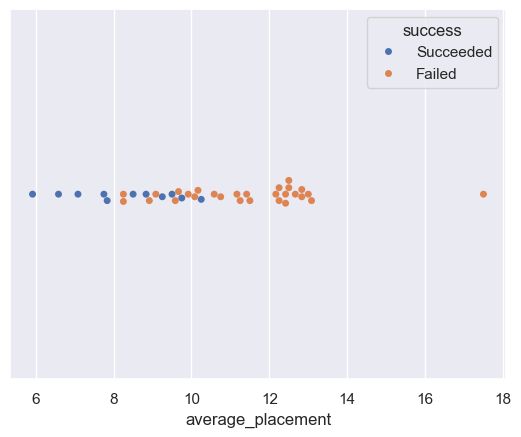

In [22]:
sns.set()
sns.swarmplot(df.replace({'success':{0:'Failed',1:'Succeeded'}}),x='average_placement', hue='success')

Of the series examined it seems that an average placement of around 10 is a cutoff point-- only one series which had a worse average placement managed to succeed.  On the other hand all five series which had an average placement of 8 or higher ended up succeeding.  Next we compare the number of successes and failures by genre.

<Axes: xlabel='genre', ylabel='count'>

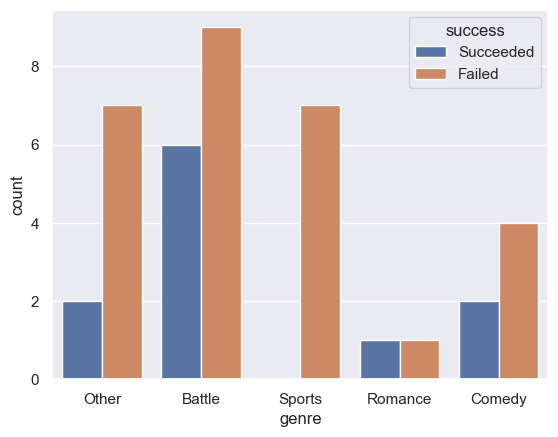

In [23]:
sns.countplot(df.replace({'success':{0:'Failed',1:'Succeeded'}}),x='genre',hue='success')

Sports stands out for having a very low success rate among the represented series.  Now we compare the number of successes and failures by batch size.

<Axes: xlabel='batch_size', ylabel='count'>

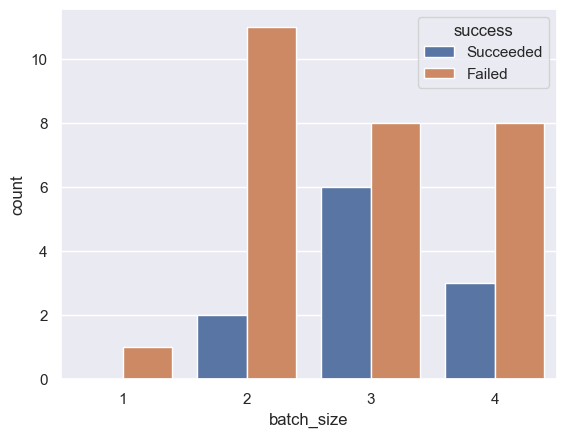

In [24]:
sns.countplot(df.replace({'success':{0:'Failed',1:'Succeeded'}}),x='batch_size',hue='success', hue_order=['Succeeded','Failed'])

It seems as if a batch size higher than 2 series may increase the odds of a series lasting for longer.  Finally we examine the success rate among single creators vs writer/artist pairs.

<Axes: xlabel='one_creator', ylabel='count'>

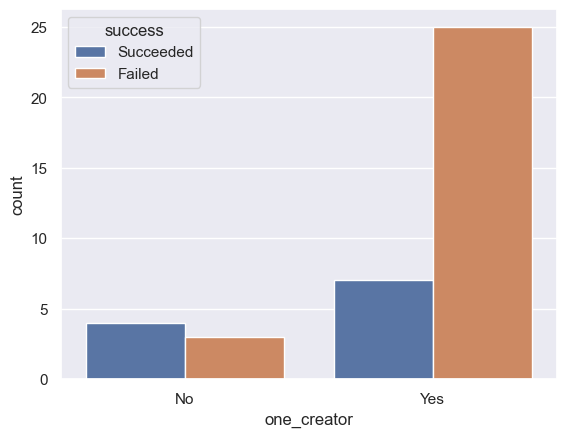

In [25]:
sns.countplot(df.replace({'success':{0:'Failed',1:'Succeeded'}, 'one_creator':{0:"No",1:'Yes'}}),
              x='one_creator',hue='success', hue_order=['Succeeded','Failed'])

Series with a separate writer and author have a higher success rate in the sample set.

## Combining Observations

From the swarm plot we might assume that it is easy to predict the success of series with an average placement better than 8 and the failure of a series with an average placement worse than 10.  But what about series in the middle?  We look to see if there is another criteria which might split the remaining data into two easy to predict blocks.

In [26]:
# Selecting series with middling placements.
middle_series=df[(df['average_placement']>8) & (df['average_placement']<10)]
middle_series

,title,genre,one_creator,success,average_placement,color_pages,cover_pages,batch_size,place_chap_1,place_chap_2,...,place_chap_5,place_chap_6,place_chap_7,place_chap_8,place_chap_9,place_chap_10,place_chap_11,place_chap_12,release_year,release_month
2,Astro Royale,Battle,1,1,8.500000,2,1,3,1,4,...,9,10,6,6,8,11,15,16,2024,4
6,Earthchild,Other,1,0,9.666667,2,1,2,1,6,...,12,8,13,12,7,11,13,14,2022,2
10,Ginka & Glüna,Battle,1,0,9.083333,2,1,2,1,6,...,12,6,12,13,11,10,12,12,2022,9
16,Ichigoki's Under Control!!,Comedy,1,0,9.916667,1,1,4,1,6,...,10,7,10,17,4,18,16,13,2022,11
18,Kagurabachi,Battle,1,1,9.250000,2,1,3,1,6,...,10,5,11,4,11,15,15,15,2023,9
22,Martial Master Asumi,Sports,1,0,8.250000,3,1,2,1,4,...,11,5,5,8,11,12,14,13,2023,6
24,Nue's Exorcist,Battle,1,1,8.833333,2,1,4,1,4,...,7,12,5,6,14,12,16,8,2023,5
28,Shinobi Undercover,Battle,0,1,9.500000,2,1,3,1,4,...,9,11,10,13,10,12,8,16,2024,9
31,Super Smartphone,Other,0,0,9.583333,2,1,3,1,6,...,8,11,11,9,15,12,13,14,2022,5
34,The Ichinose Family's Deadly Sins,Other,1,0,8.250000,2,1,4,1,4,...,12,5,14,11,7,9,7,12,2022,11


With the middle series selected we can now look at different factors which might correlate to success.  First we consider the number of color pages over the first 12 chapters.

<Axes: xlabel='color_pages', ylabel='count'>

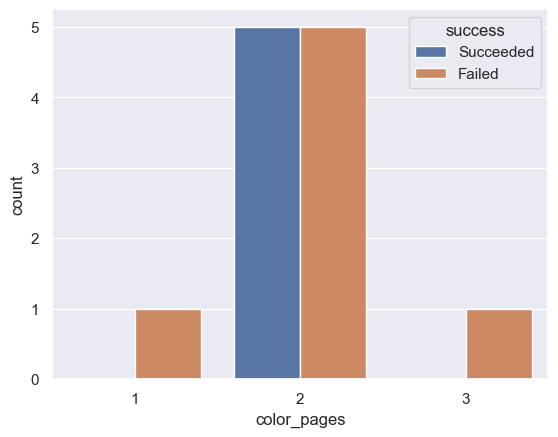

In [27]:
sns.countplot(middle_series.replace({'success':{0:'Failed',1:'Succeeded'}}),
              x='color_pages',hue='success', hue_order=['Succeeded','Failed'])

Although the only successful series from this middle cut all had 2 color pages, most of the ones which failed also had 2.  This may not be a useful axis to predict with.  Next we consider genre.

<Axes: xlabel='genre', ylabel='count'>

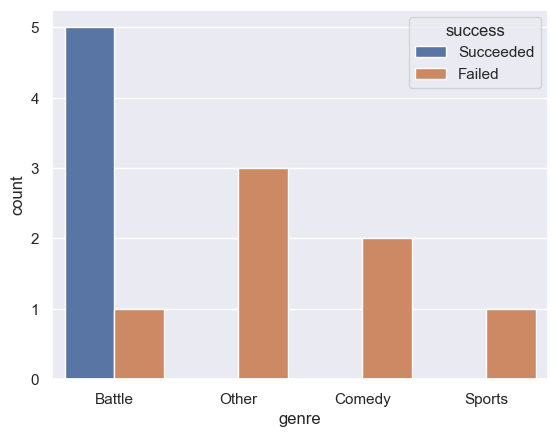

In [28]:
sns.countplot(middle_series.replace({'success':{0:'Failed',1:'Succeeded'}}),
              x='genre',hue='success', hue_order=['Succeeded','Failed'])

The above figure indicates that among the series with middling average placements those belonging to the Battle genre were the only ones to succeed (and almost all that were Battle manga *did* succeed). This might be a useful criteria in predicting the success of a series. 

# Model Creation

In this section we will create a model to predict the success of a series based on information about its initial performance in the table of contents.

## Intuition

From the above figures we might intuitively think one method of determining whether a series succeeds would be to first split the data along one axis, say the average placement in the table of contents.  Then we can predict ambiguous series using a second criteria, such as genre.  For example we could employ the following simple prediction technique:

1. If a series has an average placement better than 8 we predict it succeeds.
2. If a series has an average placement worse than 10 we predict it fails.
3. If a series has an average placement between 8 and 10 we consider its genre to make a prediction.
    * If the genre is Battle we predict it succeeds.
    * If the genre is any other we predict it fails.

This process is precisely the kind required in making a decision tree. We will create a simple tree using sklearn to demonstrate the process.

In [29]:
# We create a set of preprocessing steps to perform on different columns of our dataframe-- encoding the categorical columns
# and dropping any unneeded columns.
tree_transformers=[('OneHotEncoding', OneHotEncoder(sparse_output=False),['genre', 'release_month']),
              ('Column Dropper', 'drop', ['title','cover_pages']+chapter_placement_columns)]

# We define the preprocesser using the transformers defined above. 
tree_preprocessor=ColumnTransformer(transformers=tree_transformers,remainder='passthrough',force_int_remainder_cols=False, verbose_feature_names_out=False)

# We process the data
tree_data=tree_preprocessor.fit_transform(df.drop(['success'],axis=1))

# We extract the feature names.
tree_features=tree_preprocessor.get_feature_names_out()


# We create a decision tree classifier which we will fit using tree_data.
demo_tree=DecisionTreeClassifier(random_state=4)

# We fit the classifier on our dataset.
demo_tree.fit(tree_data,df['success'])

# We extract the class names.
tree_classes=pd.Series(demo_tree.classes_).map({0:'Fail',1:'Succeed'})


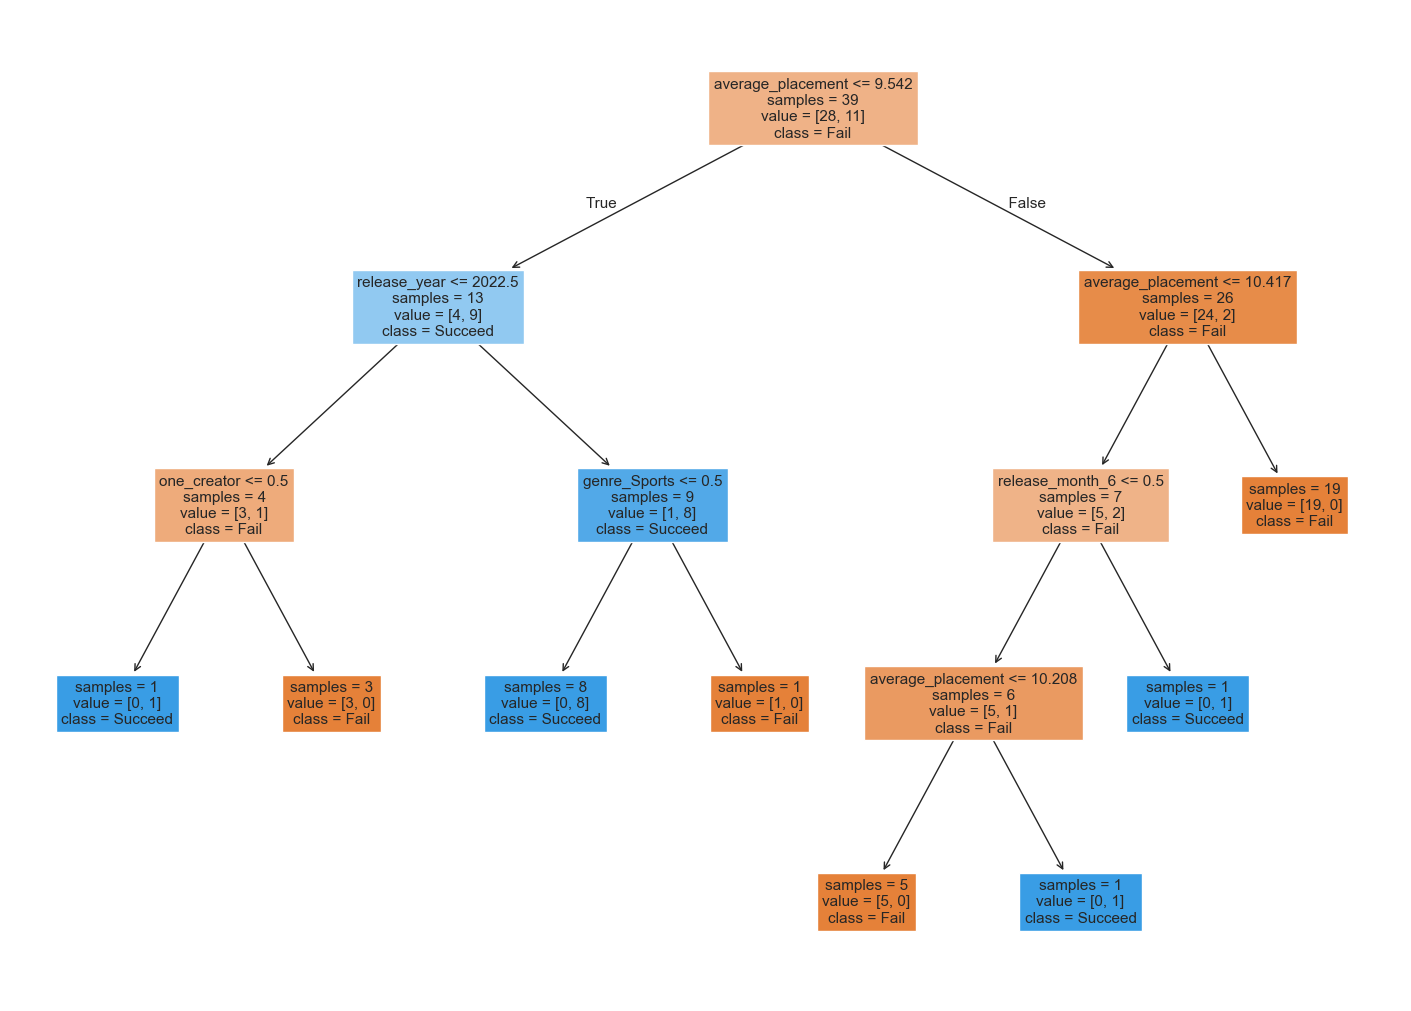

In [30]:
plt.figure(figsize=(14,10), constrained_layout=True)
plot_tree(demo_tree, feature_names=tree_features, fontsize=11, class_names=tree_classes, impurity=False, filled=True)
plt.show()

In the above plot a node is colored blue if the majority of its samples are successes and orange if the majority are failures. Following the right hand side of the tree, we notice that the tree first checks if the average placement is above or below 9.542. For samples with a worse rating, it then checks whether the placement is above or below 10.417. The leaf that follows (the 19 series with average placement larger than 10.417) includes only failures.  

The above decision tree risks overfitting the training data. When selecting the optimal model we will use cross validation and leave out a test set to better judge the quality of the model on unseen data.

## Strategy

Because the dataset is small we will rely on a leave one out cross validation strategy to select the best possible model from a grid search.  Our plan is as follows:

1. Split the dataset into a training and testing portion.  The training set will be used to fit and choose the best model, while the testing portion will help us estimate the final model's accuracy on unseen data.
2. Create a preprocessing transformer to prepare the data for the model (since many models cannot handle non-numerical data or perform better with scaled values).
3. Create a feature selector to limit the number of features considered when fitting the model.
4. Create a pipeline that will preprocess, perform feature selection, and then classify.
5. Develop a list of models and parameters for each.
6. Perform a grid search to determine which combination of features, model, and model parameters performs the most effectively.
7. Save the model for future testing as more data is obtained and the database expands.

## 1. Splitting Data
First we split the dataframe into a training and testing portion.

In [31]:
train_df, test_df = train_test_split(df,train_size=.8, random_state=3)
train_df.info()
test_df.info()

X_train=train_df.drop(['success'],axis=1)
X_test=test_df.drop(['success'],axis=1)
y_train=train_df['success']
y_test=test_df['success']

<class 'pandas.core.frame.DataFrame'>
Index: 31 entries, 27 to 24
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              31 non-null     object 
 1   genre              31 non-null     object 
 2   one_creator        31 non-null     int64  
 3   success            31 non-null     int64  
 4   average_placement  31 non-null     float64
 5   color_pages        31 non-null     int64  
 6   cover_pages        31 non-null     int64  
 7   batch_size         31 non-null     int64  
 8   place_chap_1       31 non-null     int32  
 9   place_chap_2       31 non-null     int32  
 10  place_chap_3       31 non-null     int32  
 11  place_chap_4       31 non-null     int32  
 12  place_chap_5       31 non-null     int32  
 13  place_chap_6       31 non-null     int32  
 14  place_chap_7       31 non-null     int32  
 15  place_chap_8       31 non-null     int32  
 16  place_chap_9       31 non-null  

## 2. Preprocessing

We will create a preprocessor as we did for the decision tree. Before doing so we will verify the contents of each column to determine the most fitting transformers to apply.

In [32]:
df.head()

,title,genre,one_creator,success,average_placement,color_pages,cover_pages,batch_size,place_chap_1,place_chap_2,...,place_chap_5,place_chap_6,place_chap_7,place_chap_8,place_chap_9,place_chap_10,place_chap_11,place_chap_12,release_year,release_month
0,Akane-banashi,Other,0,1,7.750000,2,1,2,1,6,...,11,8,12,9,8,10,4,6,2022,2
1,Aliens Area,Battle,1,0,11.416667,2,1,3,1,6,...,8,10,10,13,17,19,20,18,2022,6
2,Astro Royale,Battle,1,1,8.500000,2,1,3,1,4,...,9,10,6,6,8,11,15,16,2024,4
3,Cipher Academy,Other,0,1,10.250000,1,1,4,1,5,...,12,8,14,12,13,13,14,12,2022,11
4,Dear Anemone,Battle,1,0,12.250000,1,1,2,1,6,...,10,9,12,17,17,18,20,19,2024,2


Genre and release month are categorical variables and will need to be encoded. Average placement, placement, color pages, and batch size can all be scaled.  We will drop title and release date as before.  We will also drop release year to avoid training the model on faulty data since the database used only contained information up to November 2025, so the only series obtained from the SQL query debuting in 2025 must have been failures which is unlikely to be representative of the overall success/failure rate once more weeks of rankings are added.

In [33]:
transformers=[('OneHotEncoding', OneHotEncoder(sparse_output=False, handle_unknown='ignore'),['genre', 'release_month']),
              ('Scaler',StandardScaler(),['average_placement','color_pages','batch_size']+chapter_placement_columns),
              ('Column Dropper', 'drop', ['title','cover_pages', 'release_year'])]

# We define the preprocesser using the transformers defined above. 
preprocessor=ColumnTransformer(transformers=transformers, remainder='passthrough', force_int_remainder_cols=False, verbose_feature_names_out=False)
# We will include another step which uses the column names so we set the preprocessor to retain the column names (i.e. to output a dataframe)
preprocessor.set_output(transform='pandas')

ColumnTransformer(force_int_remainder_cols=False, remainder='passthrough',
                  transformers=[('OneHotEncoding',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['genre', 'release_month']),
                                ('Scaler', StandardScaler(),
                                 ['average_placement', 'color_pages',
                                  'batch_size', 'place_chap_1', 'place_chap_2',
                                  'place_chap_3', 'place_chap_4',
                                  'place_chap_5', 'place_chap_6',
                                  'place_chap_7', 'place_chap_8',
                                  'place_chap_9', 'place_chap_10',
                                  'place_chap_11', 'place_chap_12']),
                                ('Column Dropper', 'drop',
                                 ['title', 'cover_pages', 'release_year'])],
                  verbose_feature_names_out=False)

## 3. Feature Selector

We will use recursive feature elimination with a random forest model to select the best features.

In [34]:
feature_selector=RFECV(RandomForestClassifier(random_state=11),cv=3,scoring='roc_auc')

## 4. Pipeline Creation

We will create a pipeline which culminates in a decision tree classifier.  This classifier and the feature selection will be replaced by other options as we perform a grid search.

In [35]:
pipe=Pipeline(steps=[('Preprocess', preprocessor),('FeatureSelection',feature_selector),('Classifier',DecisionTreeClassifier())])

## 5. Grid Search Parameters

We create a list of dictionaries.  Each dictionary represents a classifier and the parameters we want to iterate through in the grid search.

In [36]:
# For each classifier we want to consider the behavior when using all (18) features, when only using average placement and color pages,
# when simply using average placement, and when only using the ones which recursive elimination has left us.

feature_dict={'FeatureSelection':[
    feature_selector,
    ColumnTransformer(transformers=[('KeepAll','passthrough',[])],
                      remainder='passthrough',force_int_remainder_cols=False,verbose_feature_names_out=False),
    ColumnTransformer(transformers=[('DropMost','passthrough',['average_placement','color_pages'])],
                      remainder='drop',force_int_remainder_cols=False,verbose_feature_names_out=False),
    ColumnTransformer(transformers=[('OnlyAvgPlacement','passthrough',['average_placement'])],
                      remainder='drop',force_int_remainder_cols=False,verbose_feature_names_out=False),                  
    ColumnTransformer(transformers=[('DropPlacementColumns','drop',chapter_placement_columns)],
                      remainder='passthrough',force_int_remainder_cols=False,verbose_feature_names_out=False)
]}


# Each dictionary should include a classifier and the parameters we wish to iterate through.
parameters=[
    {'Classifier':[RandomForestClassifier(random_state=3)],
     'Classifier__min_samples_leaf':[2,3,5,7]},
    {'Classifier':[DecisionTreeClassifier(random_state=3)]},
    {'Classifier':[KNeighborsClassifier()],
     'Classifier__n_neighbors':[3,5,7]},
    {'Classifier':[LogisticRegression(class_weight=None, solver='liblinear')],
     'Classifier__max_iter':[500],
     'Classifier__solver':['lbfgs', 'liblinear'],
     'Classifier__class_weight':[None,'balanced']},
    {'Classifier':[SVC(kernel='linear')],
     'Classifier__C':[.001,.01,.1,1]},
    {'Classifier':[LinearDiscriminantAnalysis()],
     'Classifier__solver':['svd','lsqr']},
    {'Classifier':[XGBClassifier()],
     'Classifier__learning_rate':[.01,.1],
     'Classifier__max_depth':[1,3,5]}

]

In [37]:
# We want to include the feature parameters in each dictionary of the parameters list.
parameters=[param|feature_dict for param in parameters]

In [38]:
# We create the grid search with the above parameters.
# We use roc_auc because we want to compare multiple binary classification models.
grid_search=GridSearchCV(pipe,param_grid=parameters,cv=5, n_jobs=-1, scoring='roc_auc', error_score='raise')

## 6. Performing the Grid Search

We will fit the grid search to the training data, select the best model, and later use the testing set to gauge accuracy on unseen data.

In [39]:
grid_search.fit(X_train,y_train)

GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('Preprocess',
                                        ColumnTransformer(force_int_remainder_cols=False,
                                                          remainder='passthrough',
                                                          transformers=[('OneHotEncoding',
                                                                         OneHotEncoder(handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         ['genre',
                                                                          'release_month']),
                                                                        ('Scaler',
                                                                         StandardScaler(),
                                                                         ['average_placement',
                                                                          'color_pages',
                                                                          'batch_size',
                                                                          'place...
                                               ColumnTransformer(force_int_remainder_cols=False,
                                                                 remainder='passthrough',
                                                                 transformers=[('DropPlacementColumns',
                                                                                'drop',
                                                                                ['place_chap_1',
                                                                                 'place_chap_2',
                                                                                 'place_chap_3',
                                                                                 'place_chap_4',
                                                                                 'place_chap_5',
                                                                                 'place_chap_6',
                                                                                 'place_chap_7',
                                                                                 'place_chap_8',
                                                                                 'place_chap_9',
                                                                                 'place_chap_10',
                                                                                 'place_chap_11',
                                                                                 'place_chap_12'])],
                                                                 verbose_feature_names_out=False)]}],
             scoring='roc_auc')

### Grid Search Results

From the above we can see that the best model found in the grid search came from using logistic regression on only two factors.  We can verify the score obtained (to be precise the average ROC-AUC score across the folds) and the best parameters as follows.

In [40]:
grid_search.best_score_

0.9099999999999999

In [41]:
grid_search.best_params_

{'Classifier': LogisticRegression(solver='liblinear'),
 'Classifier__class_weight': None,
 'Classifier__max_iter': 500,
 'Classifier__solver': 'lbfgs',
 'FeatureSelection': ColumnTransformer(force_int_remainder_cols=False,
                   transformers=[('DropMost', 'passthrough',
                                  ['average_placement', 'color_pages'])],
                   verbose_feature_names_out=False)}

To see a more complete list of results we can convert the results of the search to a dataframe and sort by their ranks.

In [42]:
results=pd.DataFrame(grid_search.cv_results_)

In [43]:
results.sort_values('rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_Classifier,param_Classifier__min_samples_leaf,param_FeatureSelection,param_Classifier__n_neighbors,param_Classifier__class_weight,param_Classifier__max_iter,...,param_Classifier__max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
42,0.025200,0.000399,0.016200,0.000747,LogisticRegression(solver='liblinear'),NaN,ColumnTransformer(force_int_remainder_cols=Fal...,NaN,None,500.0,...,NaN,{'Classifier': LogisticRegression(solver='libl...,0.8,1.0,1.0,1.000,0.7500,0.9100,0.111355,1
88,0.024213,0.001325,0.016999,0.000631,LinearDiscriminantAnalysis(),NaN,ColumnTransformer(force_int_remainder_cols=Fal...,NaN,NaN,NaN,...,NaN,"{'Classifier': LinearDiscriminantAnalysis(), '...",0.8,1.0,1.0,1.000,0.7500,0.9100,0.111355,1
83,0.025800,0.005231,0.016400,0.000800,LinearDiscriminantAnalysis(),NaN,ColumnTransformer(force_int_remainder_cols=Fal...,NaN,NaN,NaN,...,NaN,"{'Classifier': LinearDiscriminantAnalysis(), '...",0.8,1.0,1.0,1.000,0.7500,0.9100,0.111355,1
78,0.031798,0.009430,0.017598,0.002243,SVC(kernel='linear'),NaN,ColumnTransformer(force_int_remainder_cols=Fal...,NaN,NaN,NaN,...,NaN,"{'Classifier': SVC(kernel='linear'), 'Classifi...",0.8,1.0,1.0,1.000,0.7500,0.9100,0.111355,1
73,0.025000,0.002098,0.017000,0.001265,SVC(kernel='linear'),NaN,ColumnTransformer(force_int_remainder_cols=Fal...,NaN,NaN,NaN,...,NaN,"{'Classifier': SVC(kernel='linear'), 'Classifi...",0.8,1.0,1.0,1.000,0.7500,0.9100,0.111355,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,34.060482,2.443127,0.018600,0.000489,"XGBClassifier(base_score=None, booster=None, c...",NaN,"RFECV(cv=3, estimator=RandomForestClassifier(r...",NaN,NaN,NaN,...,3.0,"{'Classifier': XGBClassifier(base_score=None, ...",0.4,0.4,0.9,0.375,0.7500,0.5650,0.217715,115
25,32.523683,2.505490,0.142305,0.099621,KNeighborsClassifier(),NaN,"RFECV(cv=3, estimator=RandomForestClassifier(r...",3.0,NaN,NaN,...,NaN,"{'Classifier': KNeighborsClassifier(), 'Classi...",0.3,0.5,0.9,0.625,0.4375,0.5525,0.202855,117
26,0.023000,0.000896,0.058399,0.082304,KNeighborsClassifier(),NaN,ColumnTransformer(force_int_remainder_cols=Fal...,3.0,NaN,NaN,...,NaN,"{'Classifier': KNeighborsClassifier(), 'Classi...",0.3,0.5,0.9,0.625,0.4375,0.5525,0.202855,117
22,0.024601,0.001021,0.016999,0.000893,DecisionTreeClassifier(random_state=3),NaN,ColumnTransformer(force_int_remainder_cols=Fal...,NaN,NaN,NaN,...,NaN,{'Classifier': DecisionTreeClassifier(random_s...,0.5,0.5,0.3,0.875,0.5000,0.5350,0.186815,119


The top five models are all either logistic regression, linear SVC, or linear discriminant analysis.  We can use this information in the future if we want to perform another grid search by narrowing the list of models and increasing the diversity of parameters for each model.

To make it easier to compare models, feature selection choices, and mean test scores we will iterate through the rows of the (relatively small) dataframe of results and print these attributes nicely.

In [44]:
# We iterate through the dataframe using itertuples()
for row in results[['param_Classifier',
                    'param_FeatureSelection',
                    'mean_test_score',
                    'rank_test_score']].sort_values('rank_test_score', ascending=True).itertuples():
    # First we list the classifier name and the mean test score.
    print(f"Classifier: {row[1].__class__.__name__}. Mean test score: {row[3]}")
    # If feature selection is performed with a column transformer we list the transform.
    if isinstance(row[2],ColumnTransformer):
        print(f"Transform: {row[2].transformers[0][0]}")
    # Otherwise we list the transform as RFECV
    else:
        print("Transform: RFECV")
    print()

Classifier: LogisticRegression. Mean test score: 0.9099999999999999
Transform: DropMost

Classifier: LinearDiscriminantAnalysis. Mean test score: 0.9099999999999999
Transform: OnlyAvgPlacement

Classifier: LinearDiscriminantAnalysis. Mean test score: 0.9099999999999999
Transform: OnlyAvgPlacement

Classifier: SVC. Mean test score: 0.9099999999999999
Transform: OnlyAvgPlacement

Classifier: SVC. Mean test score: 0.9099999999999999
Transform: OnlyAvgPlacement

Classifier: LogisticRegression. Mean test score: 0.9099999999999999
Transform: OnlyAvgPlacement

Classifier: SVC. Mean test score: 0.9099999999999999
Transform: OnlyAvgPlacement

Classifier: SVC. Mean test score: 0.9099999999999999
Transform: OnlyAvgPlacement

Classifier: LogisticRegression. Mean test score: 0.9099999999999999
Transform: OnlyAvgPlacement

Classifier: LogisticRegression. Mean test score: 0.9099999999999999
Transform: OnlyAvgPlacement

Classifier: LogisticRegression. Mean test score: 0.9099999999999999
Transform: Onl

From the above we can see that the best performing models favored using only the average placement of each series when deciding success versus failure.

### Best Model
We can access the best model directly in order to score it on the testing set we left out earlier.

In [45]:
best_model=grid_search.best_estimator_
best_model

Pipeline(steps=[('Preprocess',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('OneHotEncoding',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['genre', 'release_month']),
                                                 ('Scaler', StandardScaler(),
                                                  ['average_placement',
                                                   'color_pages', 'batch_size',
                                                   'place_chap_1',
                                                   'place_chap_2',
                                                   'place_chap_3',
                                                   'place_ch...
                                                   'place_chap_11',
                                                   'place_chap_12']),
                                                 ('Column Dropper', 'drop',
                                                  ['title', 'cover_pages',
                                                   'release_year'])],
                                   verbose_feature_names_out=False)),
                ('FeatureSelection',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   transformers=[('DropMost', 'passthrough',
                                                  ['average_placement',
                                                   'color_pages'])],
                                   verbose_feature_names_out=False)),
                ('Classifier', LogisticRegression(max_iter=500))])

We will compare the performance of this model with the decision tree defined earlier.  To ensure neither have "seen" the test data we will refit the decision tree on the training set.

In [46]:
tree_data=tree_preprocessor.fit_transform(X_train)

# We fit the classifier on our training dataset.
demo_tree.fit(tree_data,y_train)

DecisionTreeClassifier(random_state=4)

First we will see the accuracy of each model on the training set.

In [47]:
print(f"The tree model scored {demo_tree.score(tree_data,y_train)} on the training set.")
print(f"The best model scored {best_model.score(X_train,y_train)} on the training set.")

The tree model scored 1.0 on the training set.
The best model scored 0.7741935483870968 on the training set.


The tree model performed far better on the training set than our best model.  However this is likely due to overfitting.  Let us compare with their performance on the test set of unseen data.

In [48]:
print(f"The tree model scored {demo_tree.score(tree_preprocessor.transform(X_test),y_test)} on the testing set.")
print(f"The best model scored {best_model.score(X_test,y_test)} on the testing set.")

The tree model scored 0.75 on the testing set.
The best model scored 1.0 on the testing set.


On unseen data the tables have completely turned and the logistic regression model performs far better.  Since the logistic regression model performed so well across cross validation we can have some confidence that it will perform robustly on unseen data.

## 7. Saving the Best Model

We conclude by saving the best model that we have obtained for future predictions and analysis.  All models will be saved in the `classifiers/demos` folder of this project.

In [49]:
# We will save the model, success_criteria, basis_size, as well as the names of the series it was fitted on as a dictionary.
file_to_save={'Model': best_model,
     'Fitted On':X_train['title'].to_list(),
     'Success Criteria': success_criteria,
     'Basis Size': basis_size}


In [50]:
file_to_save

{'Model': Pipeline(steps=[('Preprocess',
                  ColumnTransformer(force_int_remainder_cols=False,
                                    remainder='passthrough',
                                    transformers=[('OneHotEncoding',
                                                   OneHotEncoder(handle_unknown='ignore',
                                                                 sparse_output=False),
                                                   ['genre', 'release_month']),
                                                  ('Scaler', StandardScaler(),
                                                   ['average_placement',
                                                    'color_pages', 'batch_size',
                                                    'place_chap_1',
                                                    'place_chap_2',
                                                    'place_chap_3',
                                                    'place_ch...
  

In [51]:
# We get the name of the best model
model_name=best_model.named_steps['Classifier'].__class__.__name__.lower()
model_name

'logisticregression'

In [52]:
# We form the stem of the file name in the correct folder using the current date and the model name.
file_stem="classifiers/demos/"+str(date.today().strftime("%m_%d_%Y"))+f'_{model_name}'
file_stem

'classifiers/demos/03_03_2026_logisticregression'

In [53]:
# The file should be of type pkl.
file_location=file_stem+'.pkl'
file_location

'classifiers/demos/03_03_2026_logisticregression.pkl'

In [54]:
# To avoid overwriting we will stop pickle from dumping if the file already exists.  Therefore we will increment the file number in
# advance to ensure it can be saved.
if path.exists(file_stem+'.pkl'):
    file_number=1
    while path.exists(file_stem+f'_{file_number}.pkl'):
        file_number+=1
    file_location=file_stem+f'_{file_number}.pkl'

file_location

'classifiers/demos/03_03_2026_logisticregression.pkl'

In [55]:
with open(file_location, 'xb') as f:
    pickle.dump(file_to_save, f)

## Conclusions

The results of the grid search indicate that models like logistic regression, linear determinant analysis, and linear SVC may be most effective. Further, it appears that we can omit most factors and rely on the average placement when trying to predict the success or failure of a series. 

Going forward, as more chapters are added to the database, we will have more series to use in both training and testing.  A more refined grid search focusing on the parameters of the above three model types, and fewer feature selection options, might help us achieve even better results.  With a larger set we may also be able to leave aside a validation set to more completely determine which model performs best.  For instance if we had more data then we could have used our current test set for validation and set aside other data for the final test.  The code below shows how we could compare different models on such a validation set.

In [56]:
for paramset in results[results['mean_test_score']>.9]['params']:
    new_pipe=clone(pipe)
    new_pipe.set_params(**paramset)
    new_pipe.fit(X_train,y_train)
    print("Accuracy :",new_pipe.score(X_test,y_test))
    for key in paramset:
        print (key,":",paramset[key])
    print()

Accuracy : 1.0
Classifier : LogisticRegression(max_iter=500)
Classifier__class_weight : None
Classifier__max_iter : 500
Classifier__solver : lbfgs
FeatureSelection : ColumnTransformer(force_int_remainder_cols=False,
                  transformers=[('DropMost', 'passthrough',
                                 ['average_placement', 'color_pages'])],
                  verbose_feature_names_out=False)

Accuracy : 1.0
Classifier : LogisticRegression(max_iter=500)
Classifier__class_weight : None
Classifier__max_iter : 500
Classifier__solver : lbfgs
FeatureSelection : ColumnTransformer(force_int_remainder_cols=False,
                  transformers=[('OnlyAvgPlacement', 'passthrough',
                                 ['average_placement'])],
                  verbose_feature_names_out=False)

Accuracy : 1.0
Classifier : LogisticRegression(max_iter=500, solver='liblinear')
Classifier__class_weight : None
Classifier__max_iter : 500
Classifier__solver : liblinear
FeatureSelection : ColumnTransform

We may also consider the effect of changing the basis size on the prediction capability.  With more chapters to base a prediction on the "value" of the prediction may go down (as many series are canceled before even reaching 20 chapters) but the accuracy should increase. This notebook represents a first step and leaves open plenty of opportunity for further testing, improvement, and refinement.